In [3]:
from numpy.linalg import norm
from numpy.random import randn
import numpy as np
import math
from math import atan2
from filterpy.kalman import UnscentedKalmanFilter as UKF
from filterpy.common import Q_discrete_white_noise
from filterpy.kalman import unscented_transform, MerweScaledSigmaPoints
import matplotlib.pyplot as plt
import pandas as pd
import os
import random
from matplotlib import pyplot as plt

In [4]:
def load_data(PRMA, PRMP):
    df_list_MA_features = []
    df_list_MA_labels = []
    df_list_MP_features = []
    df_list_MP_labels = []
    df_day_time = []

    days = ["20181024", "20181029", "20181030","20181101"]
    times = ["0800_0830", "0830_0900", "0900_0930", "0930_1000", "1000_1030", "1030_1100"]

    for day in days:
        for timetime in times:
            # some data is not good to use
            if not os.path.exists(f"../datasets_pneuma_corrider/MA_{PRMA}_MP_{PRMP}_ma/{day}_{timetime}_MA_features.csv"):
                continue
            if day == "20181101" and timetime == "0800_0830":
                continue
            if day == "20181029" and timetime == "1000_1030":
                continue
            if day == "20181030" and timetime == "0930_1000":
                continue
            if day == "20181030" and timetime == "1000_1030":
                continue
            # read data
            df_MA_features = pd.read_csv(f"../datasets_pneuma_corrider/MA_{PRMA}_MP_{PRMP}_ma/{day}_{timetime}_MA_features.csv")
            df_list_MA_features.append(df_MA_features)
            df_MP_features = pd.read_csv(f"../datasets_pneuma_corrider/MA_{PRMA}_MP_{PRMP}_ma/{day}_{timetime}_MP_features.csv")
            df_list_MP_features.append(df_MP_features)
            df_MA_labels = pd.read_csv(f"../datasets_pneuma_corrider/MA_{PRMA}_MP_{PRMP}_ma/{day}_{timetime}_MA_labels.csv")
            df_list_MA_labels.append(df_MA_labels)
            df_MP_labels = pd.read_csv(f"../datasets_pneuma_corrider/MA_{PRMA}_MP_{PRMP}_ma/{day}_{timetime}_MP_labels.csv")
            df_list_MP_labels.append(df_MP_labels)
            # save the length of data
            df_day_time.append(len(df_MA_features))

    df_X_MA = pd.concat(df_list_MA_features)
    df_Y_MA = pd.concat(df_list_MA_labels)
    df_X_MP = pd.concat(df_list_MP_features)
    df_Y_MP = pd.concat(df_list_MP_labels)
    # delete the first column
    df_X_MA = df_X_MA.drop(df_X_MA.columns[0], axis=1)
    df_Y_MA = df_Y_MA.drop(df_Y_MA.columns[0], axis=1)
    df_X_MP = df_X_MP.drop(df_X_MP.columns[0], axis=1)
    df_Y_MP = df_Y_MP.drop(df_Y_MP.columns[0], axis=1)

    # print(df_X_MA.head(), df_Y_MA.head(), df_X_MP.head(), df_Y_MP.head())
    # print(df_X_MA.shape, df_Y_MA.shape, df_X_MP.shape, df_Y_MP.shape)

    np_X_MA = df_X_MA.values.reshape(-1, 17, 1) # counts
    np_X_MP = df_X_MP.values.reshape(-1, 17, 3) # total travel time and total travel distance
    # np_X_MP = np_X_MP[:, :, :2] # delete the speed

    np_Y_MP_qk = df_Y_MP.values.reshape(-1, 17, 3)
    np_Y_MP = np_Y_MP_qk[:, :, 1].reshape(-1, 17, 1)  # density veh/km
    # np_Y_MA = df_Y_MA.values.reshape(-1, 17, 1) * 360 / 60  # volume veh/min
    np_Y_MA = np_Y_MP_qk[:, :, 0].reshape(-1, 17, 1)  # density veh/min
    
    # merge the y of MA and MP
    np_Y = np.concatenate((np_Y_MA, np_Y_MP), axis=2)

    # split the data into train validation and test 0.6 0.2 0.2
    # train
    X_MA_train = np_X_MA[:sum(df_day_time[:-4])]
    X_MP_train = np_X_MP[:sum(df_day_time[:-4])]
    Y_train = np_Y[:sum(df_day_time[:-4])]
    # validation
    X_MA_val = np_X_MA[sum(df_day_time[:-4]):sum(df_day_time[:-3])]
    X_MP_val = np_X_MP[sum(df_day_time[:-4]):sum(df_day_time[:-3])]
    Y_val = np_Y[sum(df_day_time[:-4]):sum(df_day_time[:-3])]
    # test
    X_MA_test = np_X_MA[sum(df_day_time[:-3]):]
    X_MP_test = np_X_MP[sum(df_day_time[:-3]):]
    Y_test = np_Y[sum(df_day_time[:-3]):]

    return X_MA_train, X_MP_train, Y_train, X_MA_val, X_MP_val, Y_val, X_MA_test, X_MP_test, Y_test, df_day_time

PR = 0.2
_, _, _, _, _, _, X_MA_test, X_MP_test, Y_test, df_day_time = load_data(1, PR)
X_MP_test_1 = X_MP_test[:sum(df_day_time[-3:-2]),[2,3,8],0:2] # km/min
X_MP_test_2 = X_MP_test[sum(df_day_time[-3:-2]):sum(df_day_time[-3:-1]),[2,3,8],0:2] # km/min
X_MP_test_3 = X_MP_test[sum(df_day_time[-3:-1]):sum(df_day_time[-3:  ]),[2,3,8],0:2] # km/min
# X_MA_test_1 = X_MA_test[:sum(df_day_time[-3:-2]),[2,3,8],:] * 6 # veh/min
# X_MA_test_2 = X_MA_test[sum(df_day_time[-3:-2]):sum(df_day_time[-3:-1]),[2,3,8],:] * 6 # veh/min
# X_MA_test_3 = X_MA_test[sum(df_day_time[-3:-1]):sum(df_day_time[-3:  ]),[2,3,8],:] * 6 # veh/min
Y_test_1 = Y_test[:sum(df_day_time[-3:-2]),[2,3,8],:] # veh/km
Y_test_2 = Y_test[sum(df_day_time[-3:-2]):sum(df_day_time[-3:-1]),[2,3,8],:] # veh/km
Y_test_3 = Y_test[sum(df_day_time[-3:-1]):sum(df_day_time[-3:  ]),[2,3,8],:] # veh/km
obs_MP = np.concatenate((X_MP_test_1, X_MP_test_2, X_MP_test_3), axis=0)
label_MP = np.concatenate((Y_test_1, Y_test_2, Y_test_3), axis=0)

q_est = obs_MP[:,1,0] / (0.09822*10/60) / PR # TTD 98.22m 10s
k_est = obs_MP[:,1,1] / (0.09822*10/60) / PR # TTT 98.22m 10s
q_label = label_MP[:,1,0]
k_label = label_MP[:,1,1]

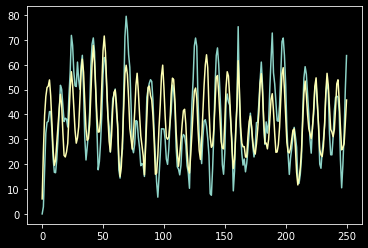

10.455388870623947 23.00241049792198


In [5]:
plt.plot(q_est, label="q_est")
plt.plot(q_label, label="k_est")
plt.show()
# calculate the rmse
rmse = np.sqrt(np.mean((q_est - q_label)**2))
# calculate the mape
mape = np.mean(np.abs((q_est - q_label) / q_label)) * 100
print(rmse, mape)

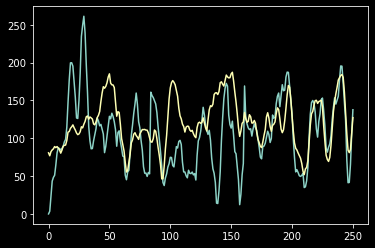

48.07403786362265 30.06144026987493


In [6]:
plt.plot(k_est, label="q_est")
plt.plot(k_label, label="k_est")
plt.show()
# calculate the rmse
rmse = np.sqrt(np.mean((k_est - k_label)**2))
# calculate the mape
mape = np.mean(np.abs((k_est - k_label) / k_label)) * 100
print(rmse, mape)